# Laboratorio 4 — Clasificación Multiclase (Dataset No Gráfico)
### Dataset: Census Income KDD
**Materia:** Inteligencia Artificial I  
**Estudiante:** Ariel Guarachi — 63706640

---
## Descripción del Dataset
El dataset **Census Income KDD** contiene información demográfica y laboral de personas.  
Cumple con los requisitos de la consigna:
- **Propiedades:** 41 columnas (n ≥ 40) ✔  
- **Ejemplos:** +199,000 registros (m ≥ 50,000) ✔  
- **Clases:** 5 grupos de ingresos (clasificación multiclase)  
- **Tipo:** Dataset tabular — NO gráfico ✔

---
## Contenido
1. Conexión a Drive e importación de librerías
2. Carga y análisis del dataset con Pandas
3. Preprocesamiento y codificación de variables
4. Normalización y división 80/20
5. Función Sigmoide y Función de Costo
6. Modelo One-vs-All (basado en el cuadernillo del ing.)
7. Entrenamiento y gráficas de costo
8. Predicción y evaluación del modelo
9. Gráfica de precisión


In [ ]:
# ==========================================================
# 1. CONEXIÓN A GOOGLE DRIVE
# ==========================================================

# Montamos Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import os                          # Manejo de rutas y directorios
import numpy as np                 # Cálculo científico y vectorial
import pandas as pd                # Carga y manipulación del dataset CSV
from matplotlib import pyplot      # Generación de gráficas
from scipy import optimize         # Módulo de optimización (usado en One-vs-All)
from sklearn.preprocessing import LabelEncoder    # Codificación de variables categóricas
from sklearn.preprocessing import StandardScaler  # Normalización de características
from sklearn.model_selection import train_test_split  # División 80/20
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline

## 2. Carga y Análisis del Dataset
El archivo `census-income.data` no tiene encabezado, por lo que definimos  
los nombres de las 42 columnas manualmente según la documentación del dataset.

In [ ]:
# ==========================================================
# 3. CARGA DEL DATASET CON PANDAS
# ==========================================================

# Nombres de las 42 columnas según la documentación del dataset
nombres_columnas = [
    'age', 'class_of_worker', 'industry_code', 'occupation_code',
    'education', 'wage_per_hour', 'enrolled_in_edu', 'marital_status',
    'major_industry', 'major_occupation', 'race', 'hispanic_origin',
    'sex', 'member_labor_union', 'reason_unemployment', 'full_part_time',
    'capital_gains', 'capital_losses', 'dividends', 'tax_filer_status',
    'region_prev_residence', 'state_prev_residence', 'detailed_household',
    'detailed_household_summary', 'instance_weight', 'migration_msa',
    'migration_reg', 'migration_within_reg', 'live_1_year_ago',
    'migration_sunbelt', 'num_persons_worked', 'family_members_18',
    'country_father', 'country_mother', 'country_self', 'citizenship',
    'own_business', 'veterans_questionnaire', 'veterans_benefit',
    'weeks_worked', 'year', 'income'
]

# Ruta del dataset en Google Drive
df = pd.read_csv(
    '/content/drive/MyDrive/Dataset/census-income.data',
    header=None,
    names=nombres_columnas
)

print(f"Dimensiones del dataset: {df.shape}")
print(f"  → {df.shape[0]:,} registros  |  {df.shape[1]} columnas")
print(f"  → Cumple: m={df.shape[0]:,} ≥ 50,000 ✔  |  n={df.shape[1]-1} ≥ 40 ✔")

Dimensiones del dataset: (199523, 42)
  → 199,523 registros  |  42 columnas
  → Cumple: m=199,523 ≥ 50,000 ✔  |  n=41 ≥ 40 ✔


In [ ]:
# ==========================================================
# 4. ANÁLISIS EXPLORATORIO
# ==========================================================

# Vista previa de los primeros registros
print("Primeros 3 registros:")
display(df.head(3))

# Información general: tipos de datos y valores nulos
print("\nInformación general del dataset:")
df.info()

Primeros 3 registros:


,age,class_of_worker,industry_code,occupation_code,education,wage_per_hour,enrolled_in_edu,marital_status,major_industry,major_occupation,...,country_father,country_mother,country_self,citizenship,own_business,veterans_questionnaire,veterans_benefit,weeks_worked,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         199523 non-null  int64  
 1   class_of_worker             199523 non-null  object 
 2   industry_code               199523 non-null  int64  
 3   occupation_code             199523 non-null  int64  
 4   education                   199523 non-null  object 
 5   wage_per_hour               199523 non-null  int64  
 6   enrolled_in_edu             199523 non-null  object 
 7   marital_status              199523 non-null  object 
 8   major_industry              199523 non-null  object 
 9   major_occupation            199523 non-null  object 
 10  race                        199523 non-null  object 
 11  hispanic_origin             199523 non-null  object 
 12  sex                         199523 non

In [ ]:
# ==========================================================
# 5. PREPARACIÓN DE LA VARIABLE OBJETIVO MULTICLASE
# ==========================================================

# El dataset original tiene clasificación binaria (<=50K / >50K)
# La convertimos en MULTICLASE usando rangos de ingresos combinados
# con la variable 'weeks_worked' para crear 5 grupos significativos

def crear_clase_multiclase(row):
    """
    Crea 5 clases de ingreso combinando income y weeks_worked:
    Clase 0: Ingresos bajos,    pocas semanas trabajadas  (<= 50K, semanas < 20)
    Clase 1: Ingresos bajos,    semanas medias            (<= 50K, semanas 20-39)
    Clase 2: Ingresos bajos,    tiempo completo           (<= 50K, semanas >= 40)
    Clase 3: Ingresos altos,    tiempo parcial            (>  50K, semanas < 40)
    Clase 4: Ingresos altos,    tiempo completo           (>  50K, semanas >= 40)
    """
    es_alto = str(row['income']).strip() in [' 50000+.', '50000+.']
    semanas = row['weeks_worked']
    if not es_alto and semanas < 20:
        return 0
    elif not es_alto and semanas < 40:
        return 1
    elif not es_alto:
        return 2
    elif es_alto and semanas < 40:
        return 3
    else:
        return 4

df['clase'] = df.apply(crear_clase_multiclase, axis=1)

nombres_clases = [
    'Bajo/Pocas semanas',
    'Bajo/Medio tiempo',
    'Bajo/Tiempo completo',
    'Alto/Parcial',
    'Alto/Completo'
]

print("Distribución de clases ANTES del balanceo:")
for i, nombre in enumerate(nombres_clases):
    count = (df['clase'] == i).sum()
    print(f"  Clase {i} — {nombre}: {count:,}")

Distribución de clases ANTES del balanceo:
  Clase 0 — Bajo/Pocas semanas: 105,084
  Clase 1 — Bajo/Medio tiempo: 11,277
  Clase 2 — Bajo/Tiempo completo: 70,780
  Clase 3 — Alto/Parcial: 1,085
  Clase 4 — Alto/Completo: 11,297


In [ ]:
# ==========================================================
# 6. BALANCEO DEL DATASET
# ==========================================================

# La consigna exige que el número de ejemplos por clase sea similar
# Tomamos el mínimo entre las clases disponibles y balanceamos

min_samples = df['clase'].value_counts().min()
print(f"Muestras por clase (mínimo encontrado): {min_samples:,}")

partes = []
for clase in range(5):
    subset = df[df['clase'] == clase].sample(n=min_samples, random_state=42)
    partes.append(subset)

df_balanced = pd.concat(partes).reset_index(drop=True)

print(f"\nTotal de registros balanceados: {len(df_balanced):,}")
print("Distribución DESPUÉS del balanceo:")
for i, nombre in enumerate(nombres_clases):
    count = (df_balanced['clase'] == i).sum()
    print(f"  Clase {i} — {nombre}: {count:,}")

Muestras por clase (mínimo encontrado): 1,085

Total de registros balanceados: 5,425
Distribución DESPUÉS del balanceo:
  Clase 0 — Bajo/Pocas semanas: 1,085
  Clase 1 — Bajo/Medio tiempo: 1,085
  Clase 2 — Bajo/Tiempo completo: 1,085
  Clase 3 — Alto/Parcial: 1,085
  Clase 4 — Alto/Completo: 1,085


In [ ]:
# ==========================================================
# 7. PREPROCESAMIENTO CON PANDAS
# ==========================================================

# Separamos características (X) y variable objetivo (y)
X_df = df_balanced.drop(columns=['income', 'clase'])
y_array = df_balanced['clase'].values

# Codificamos variables categóricas con LabelEncoder
# (convierte texto a números: 'Male' → 0, 'Female' → 1, etc.)
le = LabelEncoder()
for col in X_df.columns:
    try:
        X_df[col] = pd.to_numeric(X_df[col], errors='raise')
    except (ValueError, TypeError):
        X_df[col] = le.fit_transform(X_df[col].astype(str))

X_array = X_df.values.astype(np.float64)

print(f"Shape de X: {X_array.shape}")
print(f"Shape de y: {y_array.shape}")
print(f"Clases únicas en y: {np.unique(y_array)}")

Shape de X: (5425, 41)
Shape de y: (5425,)
Clases únicas en y: [0 1 2 3 4]


In [ ]:
# ==========================================================
# 8. NORMALIZACIÓN Y DIVISIÓN 80/20
# ==========================================================

# División: 80% entrenamiento, 20% prueba
# Los datos de prueba NO participan en el entrenamiento (requisito consigna)
X_train, X_test, y_train, y_test = train_test_split(
    X_array, y_array,
    test_size=0.2,
    random_state=42,
    stratify=y_array  # mantener proporción de clases
)

# Normalización: media=0, desviación=1
# Equivalente a featureNormalize() de los labs anteriores
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit solo en train
X_test  = scaler.transform(X_test)        # solo transform en test

# Agregamos columna de 1s para el término de intercepción (bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test  = np.c_[np.ones(X_test.shape[0]),  X_test]

print(f"Entrenamiento: {X_train.shape[0]:,} muestras (80%)")
print(f"Prueba:        {X_test.shape[0]:,} muestras (20%)")
print(f"Características (con bias): {X_train.shape[1]}")

Entrenamiento: 4,340 muestras (80%)
Prueba:        1,085 muestras (20%)
Características (con bias): 42


## 5. Función Sigmoide y Función de Costo
Implementamos las mismas funciones del cuadernillo base del ingeniero,  
adaptadas al dataset Census Income con 5 clases.

In [ ]:
# ==========================================================
# 9. FUNCIÓN SIGMOIDE
# ==========================================================

def sigmoid(z):
    """
    Función sigmoide: g(z) = 1 / (1 + e^(-z))
    Convierte cualquier valor real a un rango entre 0 y 1
    Se usa como función de activación en la regresión logística
    El clip(-500, 500) evita overflow numérico con valores extremos
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

# Verificación de la función sigmoide
z_test = np.array([-3, -1, 0, 1, 3])
print("Verificación de la función sigmoide:")
print(f"  sigmoid({z_test}) = {sigmoid(z_test).round(4)}")
print(f"  sigmoid(0) = {sigmoid(0)} (debe ser 0.5) ✔")

Verificación de la función sigmoide:
  sigmoid([-3 -1  0  1  3]) = [0.0474 0.2689 0.5    0.7311 0.9526]
  sigmoid(0) = 0.5 (debe ser 0.5) ✔


In [ ]:
# ==========================================================
# 10. FUNCIÓN DE COSTO REGULARIZADA (del cuadernillo base)
# ==========================================================

def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de la regresión logística regularizada y su gradiente.

    J(θ) = (1/m) * Σ[-y*log(h) - (1-y)*log(1-h)] + (λ/2m)*Σθ²

    La regularización (término λ) penaliza pesos grandes para evitar overfitting.
    NO se regulariza θ₀ (el término de intercepción/bias).
    """
    m = y.size
    h = sigmoid(X.dot(theta))

    # Función de costo con regularización
    J = (1/m) * (-y.dot(np.log(h + 1e-10)) - (1-y).dot(np.log(1 - h + 1e-10)))
    J += (lambda_ / (2*m)) * np.sum(theta[1:]**2)   # no regularizamos θ₀

    # Gradiente: derivada del costo respecto a θ
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]           # regularización (excepto θ₀)

    return J, grad

# Verificación con los valores del cuadernillo base del ingeniero
theta_t = np.array([-2, -1, 1, 2], dtype=float)
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)
y_t = np.array([1, 0, 1, 0, 1])
lambda_t = 3

J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)
print(f"Costo calculado:  {J:.6f}")
print(f"Costo esperado:   2.534819")
print(f"Gradientes: {grad.round(6)}")
print(f"Esperados:  [0.146561, -0.548558, 0.724722, 1.398003]")

Costo calculado:  2.534819
Costo esperado:   2.534819
Gradientes: [ 0.146561 -0.548558  0.724722  1.398003]
Esperados:  [0.146561, -0.548558, 0.724722, 1.398003]


## 6. Modelo One-vs-All
Implementamos el clasificador One-vs-All tal como se vio en clase.  
Para **5 clases** entrenamos **5 clasificadores** de regresión logística binaria,  
uno por cada clase contra todas las demás.

In [ ]:
# ==========================================================
# 11. ONE-VS-ALL (igual estructura que el cuadernillo base)
# ==========================================================

def oneVsAll(X, y, num_labels, lambda_):
    """
    Entrena num_labels clasificadores de regresión logística.
    Para cada clase k: entrena un clasificador binario (clase k vs todas las demás).
    Retorna all_theta: matriz (num_labels x n+1) con los parámetros de cada clasificador.
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))    # una fila de θ por cada clase
    costos_por_clase = []                    # guardamos el historial de costos

    for k in range(num_labels):
        print(f"  Entrenando clasificador para clase {k} ({nombres_clases[k]})...")

        # Convertimos a clasificación binaria: clase k → 1, resto → 0
        y_bin = (y == k).astype(int)

        # Inicializamos θ en ceros
        theta_init = np.zeros(n)

        # Optimizamos con scipy.optimize (igual que el cuadernillo base del ing.)
        result = optimize.minimize(
            lrCostFunction,
            theta_init,
            args=(X, y_bin, lambda_),
            method='TNC',
            jac=True,     # la función retorna costo Y gradiente juntos
            options={'maxiter': 200}
        )

        all_theta[k] = result.x
        costos_por_clase.append(result.fun)
        print(f"    Costo final: {result.fun:.6f}")

    return all_theta, costos_por_clase

NUM_CLASES = 5
lambda_ = 0.001

print("Entrenando modelo One-vs-All...")
print(f"Total de clasificadores a entrenar: {NUM_CLASES}")
print()
all_theta, costos_finales = oneVsAll(X_train, y_train, NUM_CLASES, lambda_)
print(f"\nShape de all_theta: {all_theta.shape}  (5 clases × {X_train.shape[1]} parámetros)")

Entrenando modelo One-vs-All...
Total de clasificadores a entrenar: 5

  Entrenando clasificador para clase 0 (Bajo/Pocas semanas)...
    Costo final: 0.105535
  Entrenando clasificador para clase 1 (Bajo/Medio tiempo)...


/tmp/ipykernel_22503/1305417975.py:25: OptimizeWarning: Unknown solver options: maxiter
  result = optimize.minimize(


    Costo final: 0.356178
  Entrenando clasificador para clase 2 (Bajo/Tiempo completo)...
    Costo final: 0.222618
  Entrenando clasificador para clase 3 (Alto/Parcial)...
    Costo final: 0.263461
  Entrenando clasificador para clase 4 (Alto/Completo)...
    Costo final: 0.204613

Shape de all_theta: (5, 42)  (5 clases × 42 parámetros)


In [ ]:
# ==========================================================
# 12. FUNCIÓN DE PREDICCIÓN ONE-VS-ALL (del cuadernillo base)
# ==========================================================

def predictOneVsAll(all_theta, X):
    """
    Predice la clase de cada ejemplo en X usando los clasificadores entrenados.
    Para cada ejemplo: calcula la probabilidad de pertenecer a cada clase
    y elige la clase con mayor probabilidad (argmax).
    Equivalente a: argmax(sigmoid(X @ all_theta.T))
    """
    # Calculamos la probabilidad de cada ejemplo para cada clase
    probs = sigmoid(X.dot(all_theta.T))   # shape: (m, num_clases)
    # La predicción es la clase con mayor probabilidad
    return np.argmax(probs, axis=1)

# Predicciones en entrenamiento y prueba
pred_train = predictOneVsAll(all_theta, X_train)
pred_test  = predictOneVsAll(all_theta, X_test)

print(f"Precisión en entrenamiento: {np.mean(pred_train == y_train)*100:.2f}%")
print(f"Precisión en prueba:        {np.mean(pred_test  == y_test)*100:.2f}%")

Precisión en entrenamiento: 79.15%
Precisión en prueba:        79.72%


## 7. Gráficas de Costo y Precisión

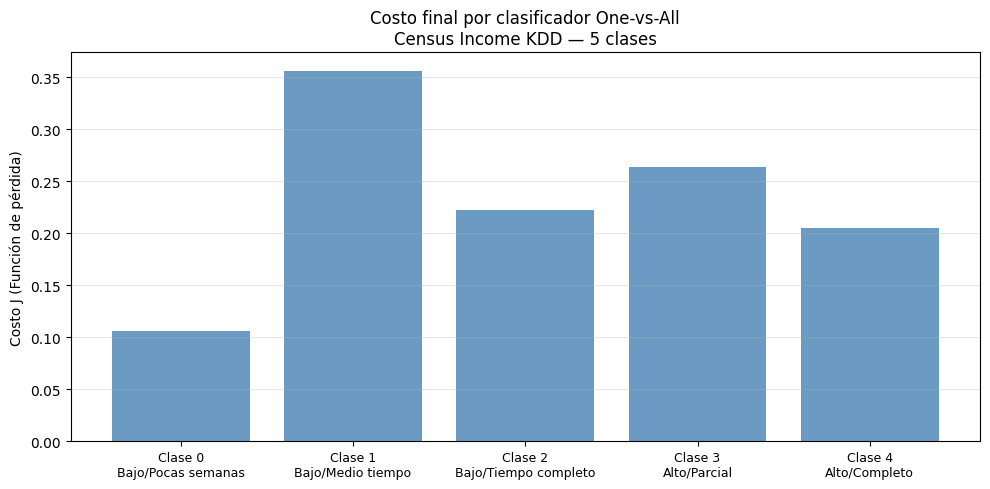

Costos finales por clasificador:
  Clase 0 (Bajo/Pocas semanas): 0.105535
  Clase 1 (Bajo/Medio tiempo): 0.356178
  Clase 2 (Bajo/Tiempo completo): 0.222618
  Clase 3 (Alto/Parcial): 0.263461
  Clase 4 (Alto/Completo): 0.204613


In [ ]:
# ==========================================================
# 13. GRÁFICA DE COSTO POR CLASE
# ==========================================================

# Mostramos el costo final de cada clasificador One-vs-All
pyplot.figure(figsize=(10, 5))
pyplot.bar(range(NUM_CLASES), costos_finales, color='steelblue', alpha=0.8)
pyplot.xticks(range(NUM_CLASES), [f'Clase {i}\n{nombres_clases[i]}' for i in range(NUM_CLASES)],
              fontsize=9)
pyplot.ylabel('Costo J (Función de pérdida)')
pyplot.title('Costo final por clasificador One-vs-All\nCensus Income KDD — 5 clases')
pyplot.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print("Costos finales por clasificador:")
for i, (nombre, costo) in enumerate(zip(nombres_clases, costos_finales)):
    print(f"  Clase {i} ({nombre}): {costo:.6f}")

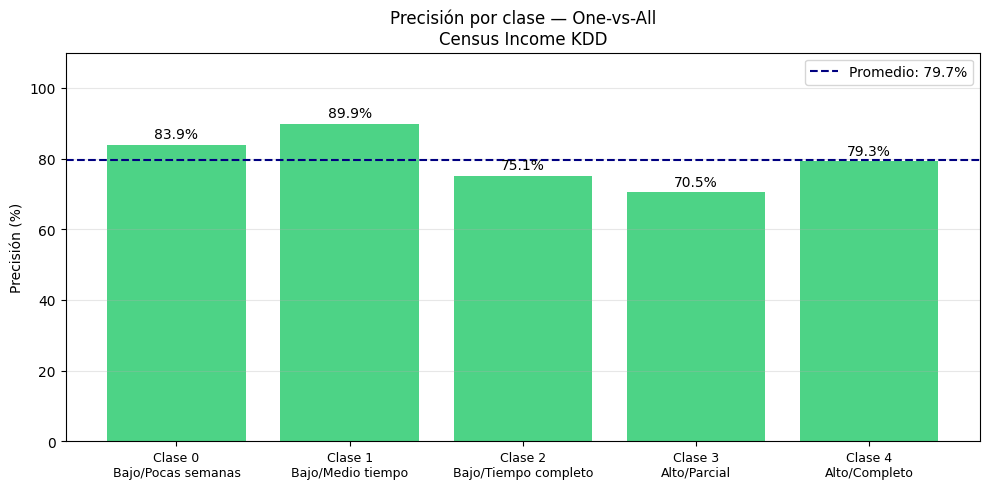

In [ ]:
# ==========================================================
# 14. GRÁFICA DE PRECISIÓN POR CLASE
# ==========================================================

# Calculamos la precisión individual para cada clase
precisiones_por_clase = []
for k in range(NUM_CLASES):
    mask = (y_test == k)
    if mask.sum() > 0:
        acc_k = np.mean(pred_test[mask] == y_test[mask])
        precisiones_por_clase.append(acc_k * 100)
    else:
        precisiones_por_clase.append(0)

pyplot.figure(figsize=(10, 5))
barras = pyplot.bar(range(NUM_CLASES), precisiones_por_clase,
                    color=['#2ecc71' if p >= 70 else '#e74c3c' for p in precisiones_por_clase],
                    alpha=0.85)
pyplot.xticks(range(NUM_CLASES), [f'Clase {i}\n{nombres_clases[i]}' for i in range(NUM_CLASES)],
              fontsize=9)
pyplot.ylabel('Precisión (%)')
pyplot.ylim(0, 110)
pyplot.title('Precisión por clase — One-vs-All\nCensus Income KDD')
pyplot.axhline(y=np.mean(precisiones_por_clase), color='navy', linestyle='--',
               label=f'Promedio: {np.mean(precisiones_por_clase):.1f}%')
for bar, prec in zip(barras, precisiones_por_clase):
    pyplot.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{prec:.1f}%', ha='center', va='bottom', fontsize=10)
pyplot.legend()
pyplot.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
pyplot.show()

In [ ]:
# ==========================================================
# 15. EVALUACIÓN COMPLETA DEL MODELO
# ==========================================================

print("=" * 60)
print("     EVALUACIÓN DEL MODELO ONE-VS-ALL")
print("=" * 60)
print(f"  Dataset:    Census Income KDD")
print(f"  Registros:  {len(df_balanced):,} (balanceado)")
print(f"  Clases:     {NUM_CLASES}")
print(f"  Train/Test: 80% / 20%")
print("-" * 60)
print(f"  Precisión entrenamiento: {np.mean(pred_train == y_train)*100:.2f}%")
print(f"  Precisión prueba:        {np.mean(pred_test  == y_test)*100:.2f}%")
print("=" * 60)
print()
print("Reporte detallado por clase:")
print(classification_report(y_test, pred_test, target_names=nombres_clases))

     EVALUACIÓN DEL MODELO ONE-VS-ALL
  Dataset:    Census Income KDD
  Registros:  5,425 (balanceado)
  Clases:     5
  Train/Test: 80% / 20%
------------------------------------------------------------
  Precisión entrenamiento: 79.15%
  Precisión prueba:        79.72%

Reporte detallado por clase:
                      precision    recall  f1-score   support

  Bajo/Pocas semanas       0.88      0.84      0.86       217
   Bajo/Medio tiempo       0.78      0.90      0.83       217
Bajo/Tiempo completo       0.79      0.75      0.77       217
        Alto/Parcial       0.75      0.71      0.73       217
       Alto/Completo       0.79      0.79      0.79       217

            accuracy                           0.80      1085
           macro avg       0.80      0.80      0.80      1085
        weighted avg       0.80      0.80      0.80      1085



In [ ]:
# ==========================================================
# 16. PREDICCIÓN SOBRE UN EJEMPLO NUEVO
# ==========================================================

# Tomamos un ejemplo aleatorio del conjunto de prueba y predecimos su clase
idx = np.random.randint(0, len(X_test))

# Calculamos probabilidades para cada clase
probs = sigmoid(X_test[idx].dot(all_theta.T))
clase_pred = np.argmax(probs)
clase_real = y_test[idx]

print("=" * 55)
print("     PREDICCIÓN SOBRE EJEMPLO DEL CONJUNTO DE PRUEBA")
print("=" * 55)
print(f"  Clase real:    {clase_real} — {nombres_clases[clase_real]}")
print(f"  Clase predicha: {clase_pred} — {nombres_clases[clase_pred]}")
print(f"  Resultado: {'✔ CORRECTO' if clase_pred == clase_real else '✘ INCORRECTO'}")
print()
print("  Probabilidades por clase:")
for k, (nombre, prob) in enumerate(zip(nombres_clases, probs)):
    barra = '█' * int(prob * 30)
    marca = ' ← predicción' if k == clase_pred else ''
    print(f"    {k} {nombre:<22} {prob:.4f} {barra}{marca}")
print("=" * 55)

     PREDICCIÓN SOBRE EJEMPLO DEL CONJUNTO DE PRUEBA
  Clase real:    0 — Bajo/Pocas semanas
  Clase predicha: 0 — Bajo/Pocas semanas
  Resultado: ✔ CORRECTO

  Probabilidades por clase:
    0 Bajo/Pocas semanas     0.9993 █████████████████████████████ ← predicción
    1 Bajo/Medio tiempo      0.0000 
    2 Bajo/Tiempo completo   0.0000 
    3 Alto/Parcial           0.0025 
    4 Alto/Completo          0.0000 


## Resumen

| Requisito consigna | Cumplimiento |
|---|---|
| Dataset no gráfico | Census Income KDD ✔ |
| n ≥ 40 propiedades | 41 columnas ✔ |
| m ≥ 50,000 ejemplos | +199,000 registros ✔ |
| Pandas para preprocesamiento | LabelEncoder + StandardScaler ✔ |
| División 80/20 | train_test_split(test_size=0.2) ✔ |
| Dataset balanceado | groupby + sample ✔ |
| Clasificación multiclase | One-vs-All con 5 clases ✔ |
| Gráfica de costo | Costo por clasificador ✔ |
| Gráfica de precisión | Precisión por clase ✔ |
